In [27]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import sys
sys.path.insert(0, '/cosma/home/dp004/dc-zhan5')
import MyHaloPS as ps
import importlib
importlib.reload(ps)
import pickle
import scipy


from scipy.optimize import curve_fit

In [2]:
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
odir1 = "../ps_data"
with open(f"{odir1}/snap40/mvir/logM_range/logM11-11.1.pickle", "rb") as f:
    Pk_mean110 = pickle.load(f)
    Pk110 = pickle.load(f)
print("shotnoise", Pk110.attrs["shotnoise"])

shotnoise 286.3949289238728


In [600]:
def my_cf(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

In [4]:
import colossus.cosmology
from colossus.lss import bias as colossus_bias
cosmo = colossus.cosmology.cosmology.setCosmology("planck15")

bias_model = "sheth01"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

bias_model = "comparat17"

z=1.5
bias0 = colossus_bias.haloBias(10**11, model=bias_model, z=z)
print(bias0)
bias0 = colossus_bias.haloBias(10**11.1, model=bias_model, z=z)
print(bias0)

1.254501032663919
1.2930499593363445
1.137078274795876
1.1740098587964916


In [595]:
from nbodykit.lab import cosmology as n_cosmology
c      = n_cosmology.Planck15
c = c.clone(P_k_max=100)
#c = n_cosmology.Cosmology(h=0.67556, T0_cmb=2.7255, Omega0_b=0.0482754208891869, Omega0_cdm=0.26377065934278865, N_ur=None, m_ncdm=[0.06], P_k_max=100.0, P_z_max=100.0, gauge='synchronous', n_s=0.9667, nonlinear=False, verbose=False)
#Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')
Plin   = n_cosmology.LinearPower(c, redshift=1.5, transfer='CLASS')

Pnl = n_cosmology.power.halofit.HalofitPower(c, redshift=1.5) 
cf_lin = n_cosmology.CorrelationFunction(Plin)
cf_nl = n_cosmology.CorrelationFunction(Pnl)

In [300]:
def kernel_lin(ks, R=1, nbins=100):
    dx = 2*R
    results = []
    r = np.linspace(0, dx, nbins)
    xi = cf_lin(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [301]:
def kernel_NL(ks, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(0, dx, nbins)
    xi = cf_nl(r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

In [593]:
def correlation_function(k_values, power_spectrum_values, r_values):
    xi_values = np.zeros_like(r_values)
    dk = k_values[1] - k_values[0]
    
    for i, r in enumerate(r_values):
        integral = np.sum(power_spectrum_values * np.sin(k_values * r) / (k_values * r) * k_values**2 * dk)
        xi_values[i] = integral / (2 * np.pi**2)
    
    return xi_values

In [594]:
def kernel_new(ks, xi, pk, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    xi = correlation_function(ks, pk,r)
    for k in ks:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

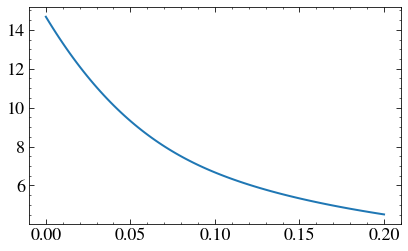

In [ ]:
R=0.1
dx=2*R
nbins=100
r = np.linspace(0, dx, nbins)
xi = cf_lin(r)
plt.plot(r, xi)

In [ ]:
def W_R(k, R=1):
    R = 2*R
    return 3 * (np.sin(k*R) - k*R*np.cos(k*R))/(k*R)**3

In [10]:
def V_excl(R=1):
    R = 2*R
    return (4*np.pi*R**3)/3

In [11]:
def pk_random(k, R):
    result2 = -V_excl(R)*W_R(k,R)
    return result2

In [302]:
def fit_pow(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="lin"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1.2
    bias_factor = bias_k**2
    
    mask = logk > -0.3
    bias_factor_k = np.full(len(logk), bias_factor)
    #bias_factor_k[mask] = bias_factor*0.5
    #bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        
        kernel = kernel_new(10**logk, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = bias_factor_k*Pk - bias_factor_k*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

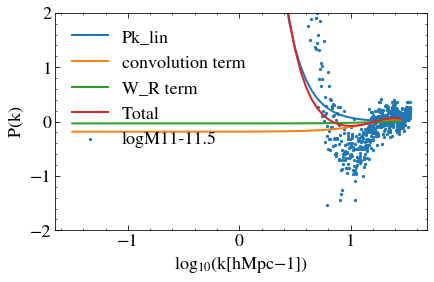

In [82]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

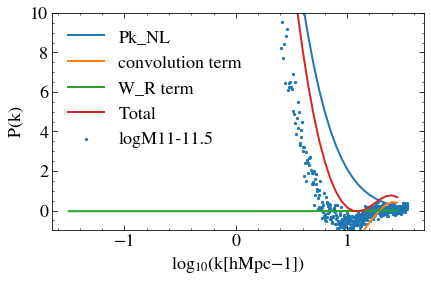

In [17]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.15
b_factor = b_const**2

plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Pnl(10**logks), label="Pk_NL")
plt.plot(logks, -b_factor*kernel_NL(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow(logks,R=R, kernel_type="nl"), label="Total")
plt.ylim(-1,1)
plt.ylim(-1,10)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

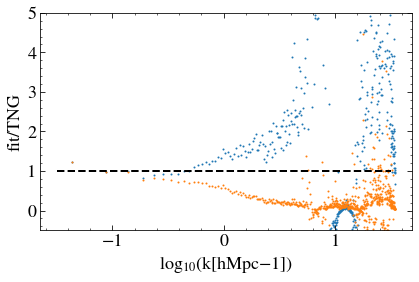

In [596]:
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)
plt.scatter(np.log10(Pk110["k"]),fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")/(Pk110["power"].real-Pk110.attrs["shotnoise"]),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

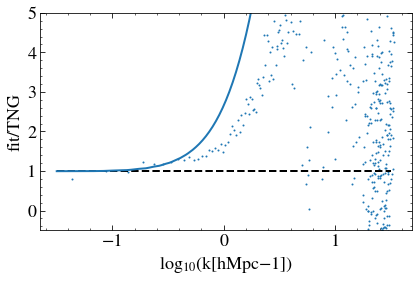

In [198]:
#plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="nl"),s=1)
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

plt.scatter(np.log10(Pk110["k"]),(Pk110["power"].real-Pk110.attrs["shotnoise"])/fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"),s=1)

plt.ylim(-0.5,5)
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.ylabel("fit/TNG")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

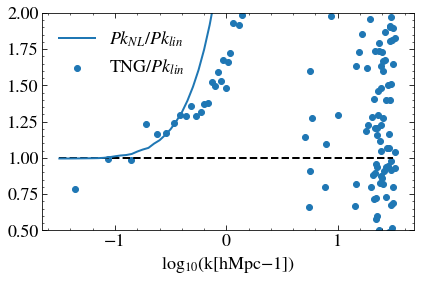

In [38]:
#ratio2[3] = Pnl(10**logk_tng[3])/Plin(10**logk_tng[3])
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin")+ V_excl(R)*W_R(Pk110["k"], R))
ratio2 = (Pk110["power"].real-Pk110.attrs["shotnoise"])/(fit_pow(np.log10(Pk110["k"]),R=R, kernel_type="lin"))

plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0.5,2)
plt.legend(loc="upper left")
plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

In [35]:
def poly3(x, a, b, c, d, x0):
    return a + b*(x-x0) + c*(x-x0)**2 + d*(x-x0)**3 

In [60]:

pop_fit1, pcov1 = curve_fit(poly3, np.log10(Pk110["k"][1:100]),ratio2[1:100],maxfev = 4000, sigma=None)
   

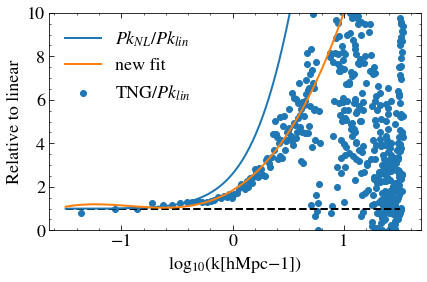

In [651]:
plt.plot(logks, Pnl(10**logks)/Plin(10**logks), label="$Pk_{NL}/Pk_{lin}$")

plt.plot(logks, poly3(logks,*pop_fit1), label="new fit")
plt.scatter(np.log10(Pk110["k"]),ratio2, label="TNG/$Pk_{lin}$")

plt.ylim(0,10)
plt.ylabel("Relative to linear")

plt.hlines(1, -1.5, 1.5, linestyle="dashed", color="k")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.legend()

In [602]:
def bias_fit(logks):
    return poly3(logks, *pop_fit1)

In [631]:
def Pnew(ks):
    logks = np.log10(ks)
    return bias_fit(logks)*Plin(ks)

In [659]:
def fit_pow_lin_kernel(logks, bias_fit, R=1, kernel_type="lin"):
  
    if kernel_type == "lin":
        Pk = Plin(10**logks)
        kernel = kernel_lin(10**logks, R=R)
    elif kernel_type == "new":
        kernel = kernel_new(10**logks, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logks)
        kernel = kernel_NL(10**logks, R=R)
    
    result1 = bias_fit(logks)*Pk - bias_fit(logks)*kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

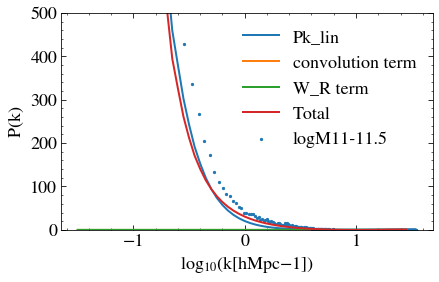

In [661]:
logks = np.arange(-1.5,1.5,0.05)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, -kernel_lin(10**logks, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_lin_kernel(logks, bias_fit, R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")

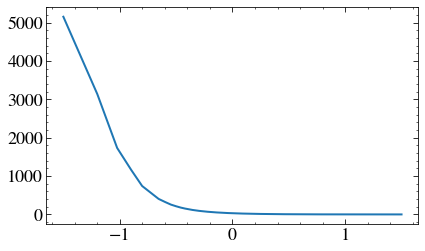

In [629]:
plt.plot(logks, bias_fit(logks)*Plin(10**logks))

In [666]:
def kernel_new(ks_out, Pnew, R=1, nbins=100):
    results = []
    dx = 2*R
    r = np.linspace(1e-4, dx, nbins)
    ks = np.linspace(10**-1.5, 10**1.5, 1000) # need many k bins in order to get good correlation function
    logks = np.log10(ks)
    xi = my_cf(ks, Pnew(ks),r)
    for k in ks_out:
        j0 = scipy.special.jv(0, k*r)
        result = 4 * np.pi * np.trapz(r**2 * xi * j0, r)
        results.append(result)
    return np.array(results)

Text(0, 0.5, '$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$')

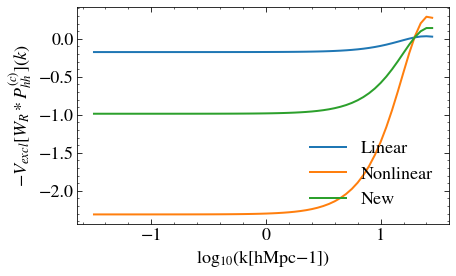

In [668]:
plt.plot(logks, -kernel_lin(10**logks, R=R), label="Linear")
plt.plot(logks, -kernel_NL(10**logks, R=R), label="Nonlinear")
plt.plot(logks, -kernel_new(10**logks, Pnew, R=R), label="New")
plt.legend()
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.ylabel("$- V_{excl}[W_R * P^{(c)}_{hh} ](k)$")

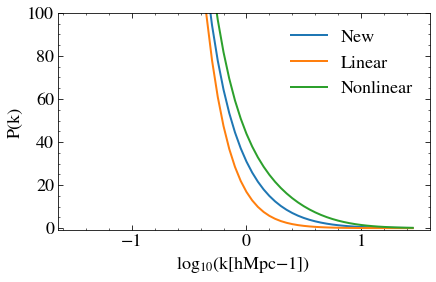

In [669]:
plt.plot(logks, Pnew(10**logks), label="New")

plt.plot(logks, Plin(10**logks), label="Linear")
plt.plot(logks, Pnl(10**logks), label="Nonlinear")
plt.ylim(-1,100)
plt.ylabel("P(k)")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")
plt.legend()

In [645]:
def fit_pow_new(logk, a=1, b=1, c=0.01, d=0.1, logk0=-0.5, R=1, kernel_type="new"):
    #bias_k = scale_dependent_bias(logk, a, b, c, d, logk0)
    bias_k = 1.2
    bias_factor = bias_k**2
    
    # mask = logk > -0.3
    # bias_factor_k = np.full(len(logk), bias_factor)
    # #bias_factor_k[mask] = bias_factor*0.5
    # bias_factor_k = poly3(logk, *pop_fit1)

    #mask = logk < logk0
    #result[mask] = a
    if kernel_type == "lin":
        Pk = Plin(10**logk)
        kernel = kernel_lin(10**logk, R=R)
    elif kernel_type == "new":
        Pk = Pnew(10**logk)
        kernel = kernel_new(10**logk, Pnew, R=R)
    elif kernel_type == "nl":
        Pk = Pnl(10**logk)
        kernel = kernel_NL(10**logk, R=R)
    
    result1 = Pk - kernel - V_excl(R)*W_R(10**logk, R)
    
    return result1

Text(0.5, 0, '$\\rm log_{10}(k [h Mpc{-1}])$')

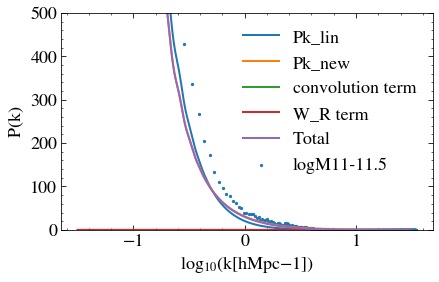

In [671]:
logks = np.arange(-1.5,1.5,0.01)
ks = 10**logks
R = 0.1
b_const = 1.1
b_factor = b_const**2
plt.scatter(np.log10(Pk110["k"]),Pk110["power"].real-Pk110.attrs["shotnoise"], s=5, label="logM11-11.5")

plt.plot(logks, b_factor*Plin(10**logks), label="Pk_lin")
plt.plot(logks, Pnew(10**logks), label="Pk_new")
plt.plot(logks, -kernel_new(10**logks,Pnew, R=R), label="convolution term")
plt.plot(logks, pk_random(ks,R), label="W_R term")
plt.plot(logks, fit_pow_new(logks,R=R), label="Total")
plt.ylim(-1,500)
#plt.ylim(-5,15)
#plt.ylim(-2,2)
plt.legend()
plt.ylabel(r"$\rm P(k)$")
plt.xlabel(r"$\rm log_{10}(k [h Mpc{-1}])$")